# EDA — Metropolitano Alimentadores

**Dataset crudo:** `data_processed/raw/alimentador_hora.parquet`
**Origen:** hoja `COSAC - ALIMENTADOR`
**Periodo:** 2025 · **Grano crudo:** ruta × sentido × paradero × fecha × hora × **tarifa**
**Guía:** `deliveries/week07/code/eda/eda_transmilenio.ipynb`

**Qué es un alimentador:** bus que conecta barrios con estaciones del troncal
(no es la pista exclusiva; “alimenta” pasajeros al Metropolitano).

| Bloque | Columnas |
|--------|----------|
| Demanda | `validaciones` |
| Ruta | `linea`, `ruta`, `sentido`, `n_paradero`, `paradero` |
| Tarifa | `tipo_tarifa` |
| Temporal | `fecha`, `hora` |


In [50]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

RAIZ = Path.cwd().resolve().parents[1]
RAW = RAIZ / "data_processed" / "raw"
CLEAN = RAIZ / "data_processed" / "clean"
FIGS = RAIZ / "docs" / "images"
CLEAN.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)

ANIO = 2025
UMBRAL_COBERTURA = 90
DIAS = ["LUN", "MAR", "MIÉ", "JUE", "VIE", "SÁB", "DOM"]
ORDEN_DIAS = DIAS

FERIADOS_PERU = {
    "2025-01-01": "Anio Nuevo", "2025-04-17": "Jueves Santo", "2025-04-18": "Viernes Santo",
    "2025-05-01": "Dia del Trabajo", "2025-06-29": "San Pedro y San Pablo",
    "2025-07-29": "Fiestas Patrias", "2025-08-30": "Santa Rosa de Lima",
    "2025-10-08": "Combate de Angamos", "2025-11-01": "Todos los Santos",
    "2025-12-08": "Inmaculada Concepcion", "2025-12-25": "Navidad",
}

MAPA_SENTIDO = {
    "NS": ("NS", "N->S"), "SN": ("NS", "S->N"),
    "NORTE-SUR": ("NS", "N->S"), "SUR-NORTE": ("NS", "S->N"),
    "OE": ("EO", "E->O"), "EO": ("EO", "O->E"),
    "OESTE-ESTE": ("EO", "E->O"), "ESTE-OESTE": ("EO", "O->E"),
    "IDA": ("NS", "N->S"), "VUELTA": ("NS", "S->N"),
    "N->S": ("NS", "N->S"), "S->N": ("NS", "S->N"),
    "E->O": ("EO", "E->O"), "O->E": ("EO", "O->E"),
    "N-S": ("NS", "N->S"), "S-N": ("NS", "S->N"),
}

COLOR = "#c0504d"
SISTEMA = "alimentador"

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 10,
    "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False,
    "axes.spines.right": False, "figure.autolayout": True,
})
sns.set_style("whitegrid")


def guardar_fig(nombre: str) -> None:
    destino = FIGS / nombre
    plt.savefig(destino, bbox_inches="tight")
    plt.show()  # inline en la celda + archivo en docs/images
    plt.close()
    print(f"  [figura] {destino.relative_to(RAIZ)}")


def anadir_calendario(df: pd.DataFrame) -> pd.DataFrame:
    f = pd.to_datetime(df["fecha"], errors="coerce")
    out = df.copy()
    out["fecha"] = f.dt.normalize()
    out["anio"] = f.dt.year.astype("Int16")
    out["mes"] = f.dt.month.astype("Int8")
    dow = f.dt.dayofweek
    out["dia_semana"] = [DIAS[int(i)] if pd.notna(i) else None for i in dow]
    out["tipo_dia"] = np.select(
        [dow.isna(), dow <= 4, dow == 5, dow == 6],
        [None, "LAB", "SAB", "DOM"], default=None,
    )
    out["semana_iso"] = f.dt.isocalendar().week.astype("Int16")
    clave = out["fecha"].dt.strftime("%Y-%m-%d")
    out["feriado"] = clave.map(FERIADOS_PERU)
    out["es_feriado"] = out["feriado"].notna()
    return out


def ids_texto(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        if c in out.columns:
            out[c] = (out[c].astype("string").str.replace(r"\.0$", "", regex=True).str.strip())
    return out


def normalizar_sentido(df: pd.DataFrame, col: str = "sentido") -> pd.DataFrame:
    out = df.copy()
    bruto = out[col].astype("string").str.strip().str.upper()
    par = bruto.map(MAPA_SENTIDO)
    out["sentido_norm"] = par.map(lambda t: t[1] if isinstance(t, tuple) else None)
    out["eje"] = par.map(lambda t: t[0] if isinstance(t, tuple) else None)
    out["sentido_crudo"] = bruto
    return out


def marcar_franja(hora: pd.Series) -> pd.Series:
    return pd.cut(
        hora.astype(int),
        bins=[-1, 5, 9, 15, 20, 24],
        labels=["madrugada", "pico_am", "valle", "pico_pm", "noche"],
    )


def iqr_bounds(s: pd.Series, k: float = 1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return float(q1 - k * iqr), float(q3 + k * iqr), float(q1), float(q3), float(iqr)


print(f"Sistema: {SISTEMA}")
print(f"RAW  : {RAW}")
print(f"CLEAN: {CLEAN}")


Sistema: alimentador
RAW  : /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/data_processed/raw
CLEAN: /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/data_processed/clean


## 1. Carga del dataset crudo


In [51]:
ruta = RAW / "alimentador_hora.parquet"
if not ruta.exists():
    raise FileNotFoundError(f"Falta {ruta}. Ejecuta prepare_parquet.py --anio {ANIO}")
df = pd.read_parquet(ruta)
print(f"Filas: {len(df):,} | Columnas: {list(df.columns)}")
# el crudo es grande (~18M); mostramos muestra
df.head()


Filas: 18,681,216 | Columnas: ['fecha', 'linea', 'ruta', 'sentido', 'n_paradero', 'paradero', 'hora', 'tipo_tarifa', 'validaciones']


,fecha,linea,ruta,sentido,n_paradero,paradero,hora,tipo_tarifa,validaciones
0,2025-01-01,305,Alisos ...,N->S,5616,Estación Naranjal Embarque Nº 14,0,Escolar,NaN
1,2025-01-01,305,Alisos ...,N->S,5616,Estación Naranjal Embarque Nº 14,0,General,NaN
2,2025-01-01,305,Alisos ...,N->S,5616,Estación Naranjal Embarque Nº 14,0,Libre,NaN
3,2025-01-01,305,Alisos ...,N->S,5616,Estación Naranjal Embarque Nº 14,0,Universitario,NaN
4,2025-01-01,305,Alisos ...,N->S,5616,Estación Naranjal Embarque Nº 14,1,Escolar,NaN


## 2. Inspección inicial


In [52]:
info = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "nulos_%": (100 * df.isna().mean()).round(2),
    "unicos": df.nunique(dropna=False),
})
print(info.to_string())
df[["validaciones"]].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).T


                       dtype     nulos  nulos_%  unicos
fecha         datetime64[us]         0     0.00     364
linea                  int64         0     0.00      30
ruta                     str         0     0.00      27
sentido                  str         0     0.00       2
n_paradero             int64         0     0.00     652
paradero                 str    137472     0.74     535
hora                   int64         0     0.00      24
tipo_tarifa              str         0     0.00       4
validaciones         float64  12117848    64.87     501


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
validaciones,6563368.0,3.03225,12.819791,0.0,0.0,0.0,0.0,0.0,2.0,13.0,48.0,568.0


## 3. Limpieza

### 3.1 Calendario, IDs y sentidos

Además: se construye el **total** (suma de tarifas) y el mix tarifario.


In [53]:
df_raw_n = len(df)
df = anadir_calendario(df)
df = ids_texto(df, ["ruta", "n_paradero", "paradero", "linea"])
df["hora"] = pd.to_numeric(df["hora"], errors="coerce").astype("Int16")
df["validaciones"] = pd.to_numeric(df["validaciones"], errors="coerce")
antes = len(df)
df["era_celda_vacia"] = df["validaciones"].isna()
n_na = int(df["era_celda_vacia"].sum())
n_zero_escritos = int((df["validaciones"] == 0).sum())
df["validaciones"] = pd.to_numeric(df["validaciones"], errors="coerce").fillna(0)
df = df[df["validaciones"] >= 0].copy()  # conserva ceros; NA→0+flag
print(f"NA→0+flag: {n_na:,} | ceros escritos: {n_zero_escritos:,} | filas panel={len(df):,}")
print(f"crudo={df_raw_n:,} -> tras NA→0+flag (ceros conservados)={len(df):,} ({100*len(df)/antes:.2f}% del prefiltro)")


NA→0+flag: 12,117,848 | ceros escritos: 3,907,829 | filas panel=18,681,216
crudo=18,681,216 -> tras NA→0+flag (ceros conservados)=18,681,216 (100.00% del prefiltro)


### 3.2 Mix tarifario y agregado sin tarifa


In [54]:
mix = (df.groupby(["fecha", "ruta", "hora", "tipo_tarifa"], as_index=False, dropna=False)["validaciones"].sum())
print("Mix tarifario filas:", len(mix), "| tarifas:", mix["tipo_tarifa"].value_counts().to_dict())

total = (df.groupby(
    ["fecha","anio","mes","dia_semana","tipo_dia","semana_iso","feriado","es_feriado",
     "linea","ruta","sentido","n_paradero","paradero","hora"],
    as_index=False, dropna=False)["validaciones"].sum())
flag = (df.groupby([
    "fecha","linea","ruta","sentido","n_paradero","paradero","hora"], as_index=False)
    ["era_celda_vacia"].max())
total = total.merge(flag, on=["fecha","linea","ruta","sentido","n_paradero","paradero","hora"], how="left")
total = normalizar_sentido(total)
print(f"Total agregado: {len(total):,} | sin sentido_norm: {total['sentido_norm'].isna().sum()}")
print(total["sentido_crudo"].value_counts(dropna=False).head().to_string())
df = total  # a partir de aquí el EDA usa el total por paradero-hora


Mix tarifario filas: 804864 | tarifas: {'Escolar': 201216, 'General': 201216, 'Libre': 201216, 'Universitario': 201216}
Total agregado: 4,670,304 | sin sentido_norm: 0
sentido_crudo
S->N    2876544
N->S    1793760


### 3.3 Cobertura por ruta


              ruta  dias_con_datos  dias_esperados  pct_cobertura  fiable
         Expreso 1               1             365            0.3   False
         Regular C               1             365            0.3   False
     Santo Domingo               1             365            0.3   False
Circuito de Playas              24             365            6.6   False
             Payet             359             365           98.4    True
          Trapiche             361             365           98.9    True
     Tahuantinsuyo             362             365           99.2    True
          Collique             363             365           99.5    True
          Naranjal             363             365           99.5    True
     Universitaria             363             365           99.5    True
  San Juan de Dios             363             365           99.5    True
          Belaunde             363             365           99.5    True
        Carabayllo             364    

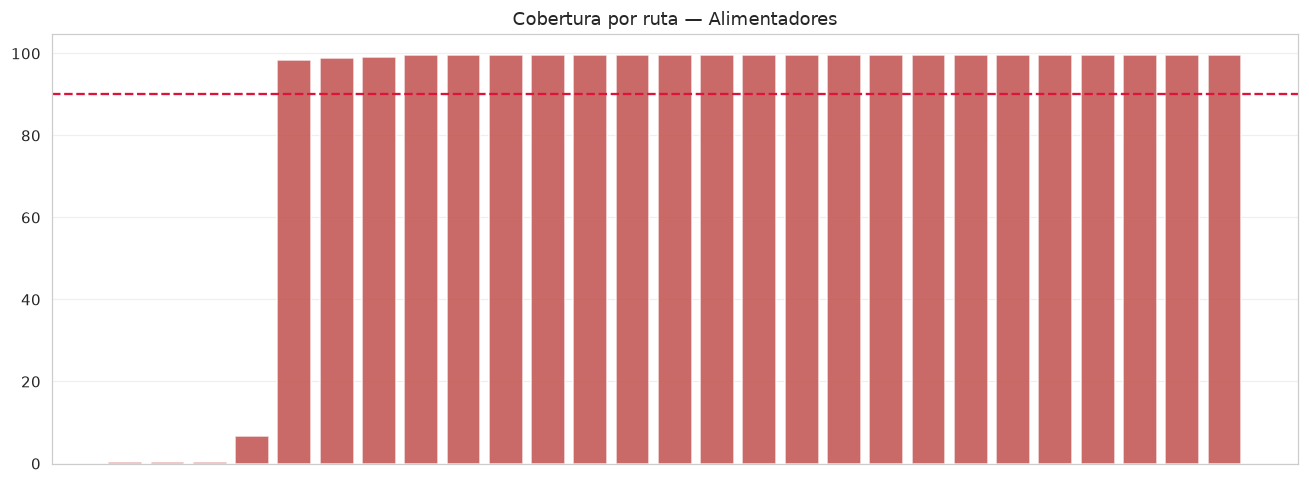

  [figura] docs/images/eda_alimentador_cobertura.png
Filas en rutas fiables: 4,667,184


In [55]:
dias_esperados = pd.date_range(f"{ANIO}-01-01", f"{ANIO}-12-31").normalize().nunique()
cob = (df.groupby("ruta")["fecha"].nunique().rename("dias_con_datos").reset_index())
cob["dias_esperados"] = dias_esperados
cob["pct_cobertura"] = (100 * cob["dias_con_datos"] / dias_esperados).round(1)
cob["fiable"] = cob["pct_cobertura"] >= UMBRAL_COBERTURA
print(cob.sort_values("pct_cobertura").to_string(index=False))
print(f"Fiables: {cob['fiable'].sum()}/{len(cob)} — ninguna suele llegar a 365 días")
fig, ax = plt.subplots(figsize=(12, 4.5))
orden = cob.sort_values("pct_cobertura")
ax.bar(range(len(orden)), orden["pct_cobertura"], color=COLOR, alpha=0.85)
ax.axhline(UMBRAL_COBERTURA, color="crimson", ls="--")
ax.set_xticks([]); ax.set_title("Cobertura por ruta — Alimentadores")
guardar_fig("eda_alimentador_cobertura.png")
rutas_fiables = set(cob.loc[cob["fiable"], "ruta"].astype(str))
df_f = df[df["ruta"].astype(str).isin(rutas_fiables)].copy() if rutas_fiables else df.copy()
print(f"Filas en rutas fiables: {len(df_f):,}")


## 4. Feature engineering


In [56]:
df["franja"] = marcar_franja(df["hora"])
df["log_val"] = np.log1p(df["validaciones"])
diario = (df.groupby(["ruta", "fecha"], as_index=False)["validaciones"].sum()
          .rename(columns={"validaciones": "val_dia"}))
lo, hi, q1, q3, iqr = iqr_bounds(diario["val_dia"])
diario["es_outlier_iqr"] = (diario["val_dia"] < lo) | (diario["val_dia"] > hi)
df = df.merge(diario[["ruta", "fecha", "es_outlier_iqr"]], on=["ruta", "fecha"], how="left")
print(f"IQR ruta-día: [{lo:,.0f}, {hi:,.0f}] | outliers={diario['es_outlier_iqr'].mean():.2%}")


IQR ruta-día: [-2,290, 6,468] | outliers=4.20%


## 5. Outliers (IQR) — ¿borrarlos?

**Decisión: NO eliminarlos del dataset limpio.** En demanda de transporte los
valores fuera de [Q1 − 1.5·IQR, Q3 + 1.5·IQR] suelen ser **picos reales**
(días de hub, eventos, punta acumulada). Borrar outliers sesgaría justo la cola
que un modelo de aforo/espera necesita aprender.

Sí los **marcamos** (`es_outlier_iqr`) para inspeccionarlos, estratificar el
análisis y, si hace falta, usar `log1p` en modelado.


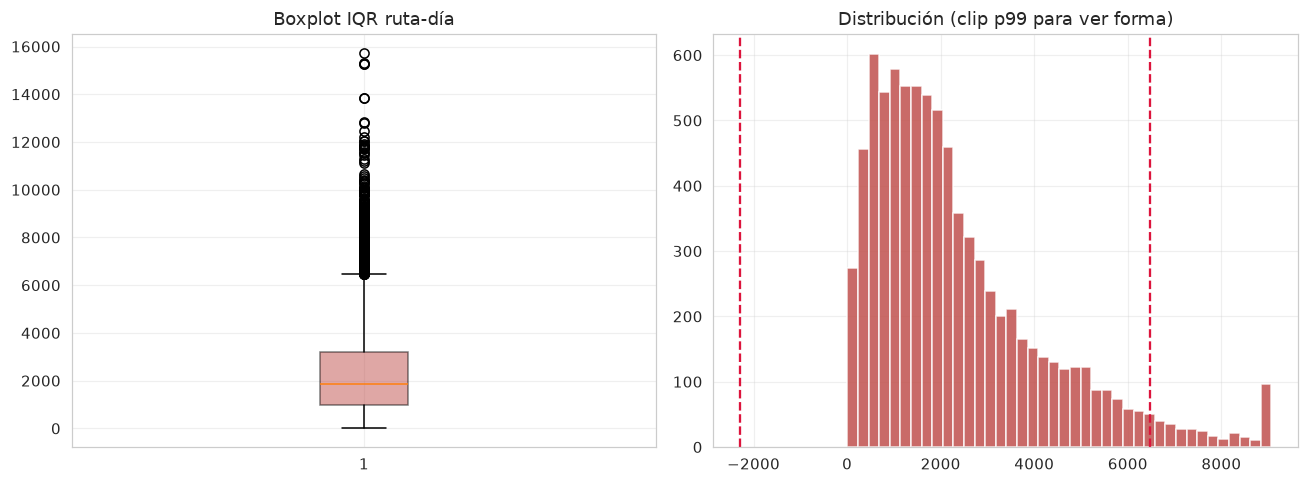

  [figura] docs/images/eda_alimentador_outliers_iqr.png


In [57]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].boxplot(diario["val_dia"], showfliers=True, patch_artist=True,
                boxprops=dict(facecolor=COLOR, alpha=0.5))
axes[0].set_title("Boxplot IQR ruta-día")
axes[1].hist(diario["val_dia"].clip(upper=diario["val_dia"].quantile(0.99)), bins=40, color=COLOR, alpha=0.85)
axes[1].axvline(lo, color="crimson", ls="--"); axes[1].axvline(hi, color="crimson", ls="--")
axes[1].set_title("Distribución (clip p99 para ver forma)")
guardar_fig("eda_alimentador_outliers_iqr.png")


## 6. Análisis

### 6.1 Univariado y serie


Total: 19,901,771 | rutas=27 | líneas=30


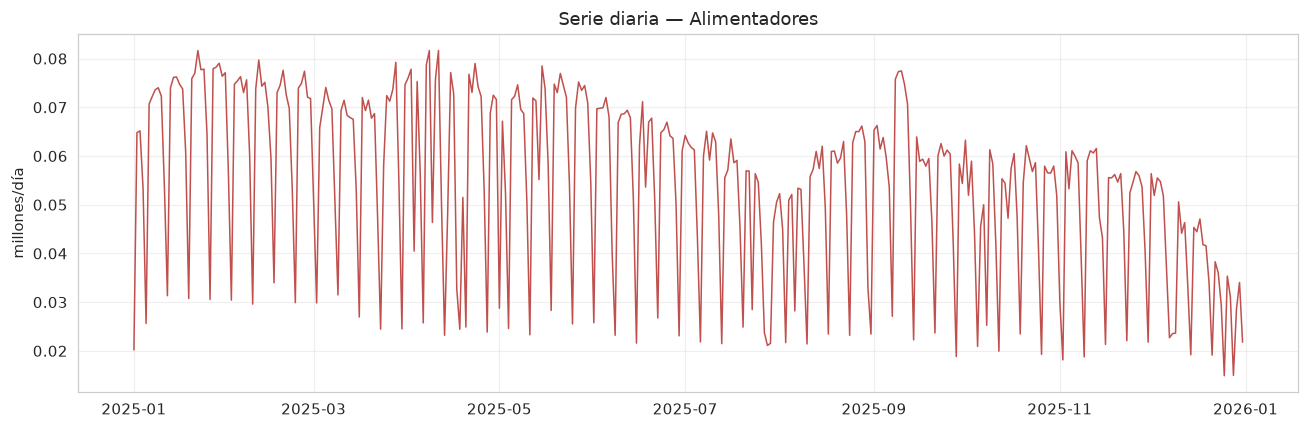

  [figura] docs/images/eda_alimentador_serie_diaria.png


In [58]:
print(f"Total: {df['validaciones'].sum():,.0f} | rutas={df['ruta'].nunique()} | líneas={df['linea'].nunique()}")
serie = df.groupby("fecha")["validaciones"].sum()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(serie.index, serie.values / 1e6, color=COLOR, lw=1)
ax.set_title("Serie diaria — Alimentadores"); ax.set_ylabel("millones/día")
guardar_fig("eda_alimentador_serie_diaria.png")


### 6.2 Perfil horario vs troncal-like (bivariado)


hora
7     10.0
6      9.0
18     9.0
19     9.0
20     7.0
06-10h 33.8% | 16-20h 34.6%


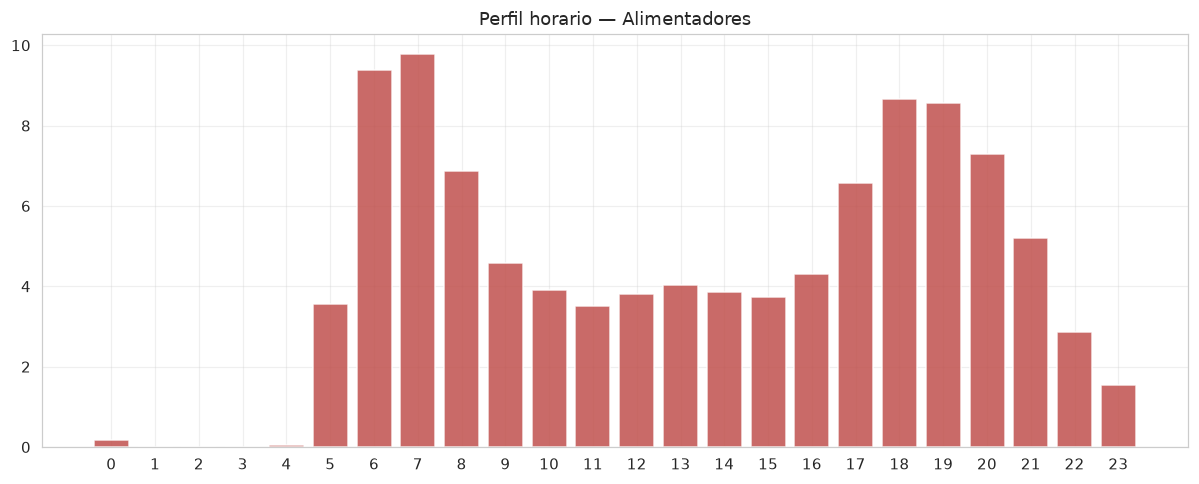

  [figura] docs/images/eda_alimentador_perfil_horario.png


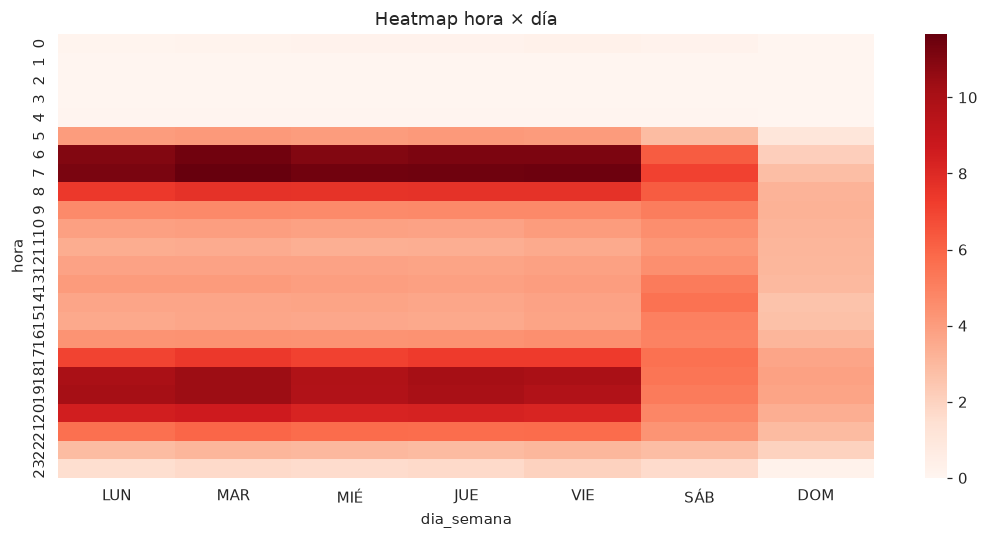

  [figura] docs/images/eda_alimentador_heatmap_hora_dia.png


In [59]:
perfil = df.groupby("hora")["validaciones"].mean()
pct = 100 * perfil / perfil.sum()
print(perfil.nlargest(5).round(0).to_string())
print(f"06-10h {pct[(pct.index>=6)&(pct.index<=10)].sum():.1f}% | 16-20h {pct[(pct.index>=16)&(pct.index<=20)].sum():.1f}%")
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(perfil.index, perfil.values, color=COLOR, alpha=0.85, width=0.8)
ax.set_xticks(range(0, 24)); ax.set_title("Perfil horario — Alimentadores")
guardar_fig("eda_alimentador_perfil_horario.png")
hm = df.pivot_table(index="hora", columns="dia_semana", values="validaciones", aggfunc="mean").reindex(columns=ORDEN_DIAS)
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(hm, cmap="Reds", ax=ax); ax.set_title("Heatmap hora × día")
guardar_fig("eda_alimentador_heatmap_hora_dia.png")


### 6.3 Ranking de líneas y sentidos


       validaciones  dias  rutas  share_%
linea                                    
106       2646966.0   364      1     13.0
333       1712729.0   364      1      9.0
308       1435381.0   364      1      7.0
322       1378505.0   297      1      7.0
305       1308142.0   364      1      7.0
304       1256149.0   364      1      6.0
317        960472.0   363      1      5.0
102        950490.0   364      1      5.0
311        884234.0   363      1      4.0
314        877773.0   364      1      4.0
315        765533.0   364      1      4.0
318        670921.0   363      1      3.0
425        628085.0   364      1      3.0
307        613102.0   363      1      3.0
107        600904.0   364      1      3.0
108        557434.0   364      1      3.0
320        513639.0   363      1      3.0
325        379646.0   248      1      2.0
301        377265.0   359      1      2.0
310        372180.0   364      1      2.0


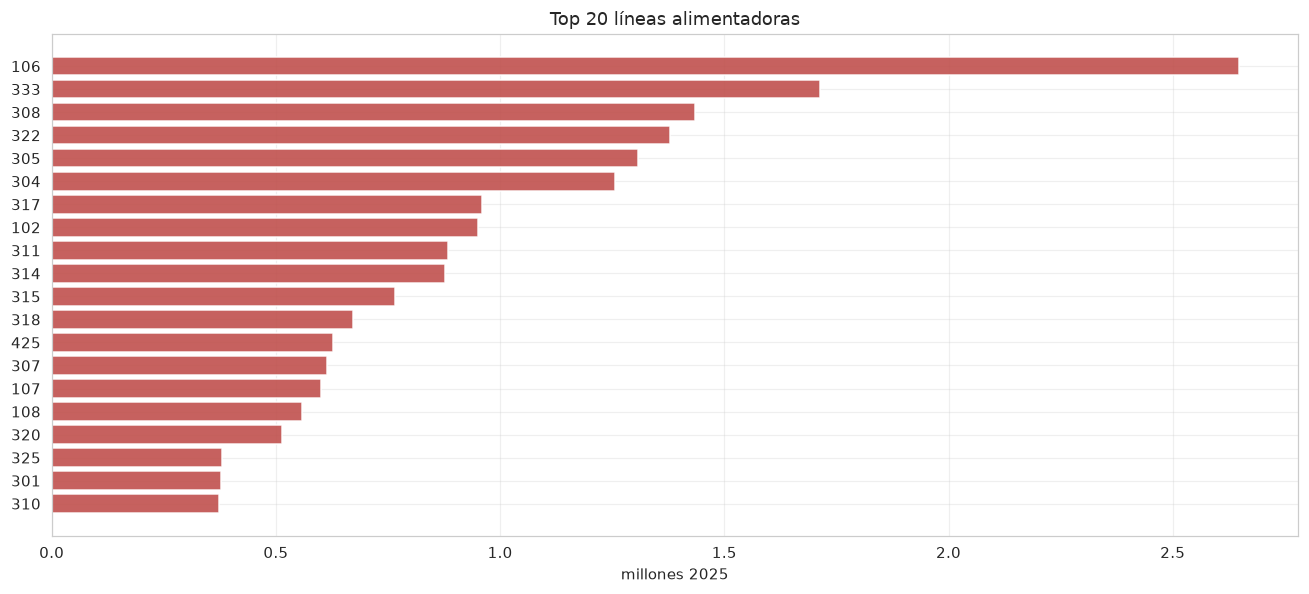

  [figura] docs/images/eda_alimentador_ranking_lineas.png

Por sentido_norm:
sentido_norm
N->S     8808504.0
S->N    11093267.0


In [60]:
por_linea = (df.groupby("linea").agg(validaciones=("validaciones","sum"), dias=("fecha","nunique"),
                                     rutas=("ruta","nunique")).sort_values("validaciones", ascending=False))
por_linea["share_%"] = (100 * por_linea["validaciones"] / por_linea["validaciones"].sum()).round(1)
print(por_linea.head(20).round(0).to_string())
fig, ax = plt.subplots(figsize=(12, 5.5))
top = por_linea.sort_values("validaciones").tail(20)
ax.barh(top.index.astype(str), top["validaciones"] / 1e6, color=COLOR, alpha=0.9)
ax.set_title("Top 20 líneas alimentadoras"); ax.set_xlabel("millones 2025")
guardar_fig("eda_alimentador_ranking_lineas.png")
print("\nPor sentido_norm:")
print(df.groupby("sentido_norm")["validaciones"].sum().to_string())


### 6.4 Mezcla tarifaria


tipo_tarifa
General          83.3
Universitario    13.8
Escolar           2.1
Libre             0.7


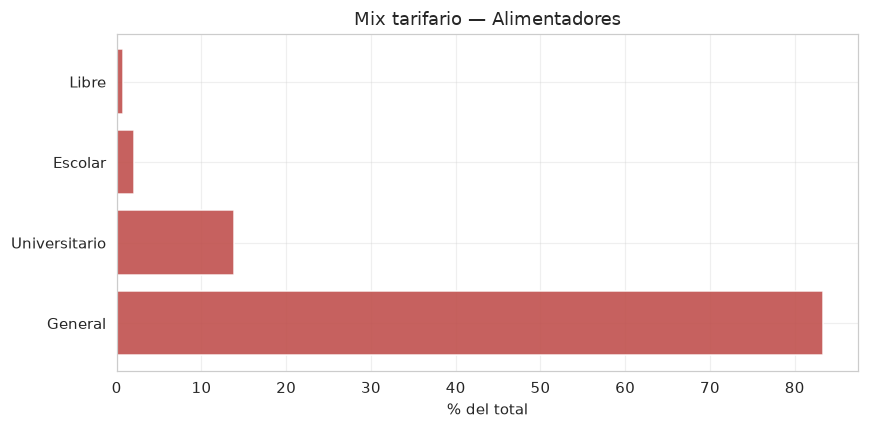

  [figura] docs/images/eda_alimentador_tarifas.png


In [61]:
part = (mix.groupby("tipo_tarifa")["validaciones"].sum() / mix["validaciones"].sum() * 100).round(1).sort_values(ascending=False)
print(part.to_string())
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(part.index, part.values, color=COLOR, alpha=0.9)
ax.set_xlabel("% del total"); ax.set_title("Mix tarifario — Alimentadores")
guardar_fig("eda_alimentador_tarifas.png")


### 6.5 Correlación (ruta × día)


                 val_dia  hora_media_pond  n_paraderos    mes    dow  es_feriado_i
val_dia            1.000           -0.145        0.442 -0.160 -0.230        -0.116
hora_media_pond   -0.145            1.000        0.026  0.023  0.066         0.031
n_paraderos        0.442            0.026        1.000 -0.155 -0.153        -0.065
mes               -0.160            0.023       -0.155  1.000 -0.012         0.039
dow               -0.230            0.066       -0.153 -0.012  1.000         0.008
es_feriado_i      -0.116            0.031       -0.065  0.039  0.008         1.000


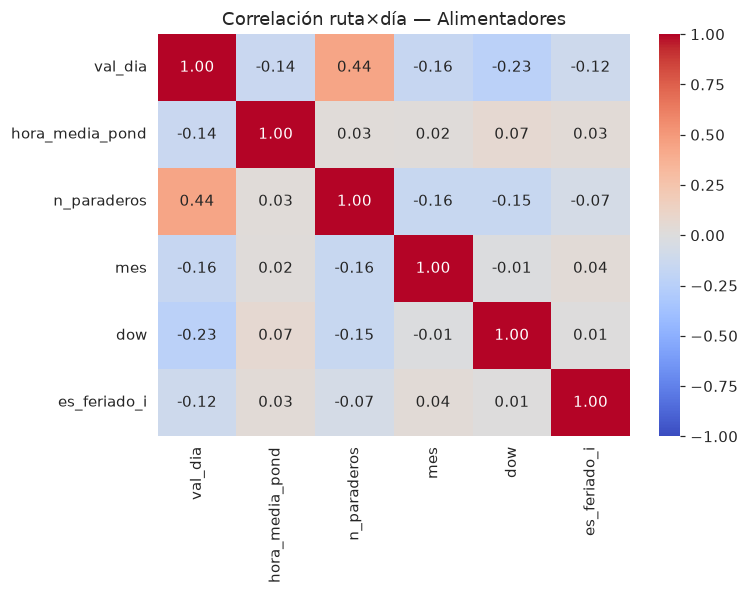

  [figura] docs/images/eda_alimentador_correlacion.png


In [62]:
tmp = (df.groupby(["ruta", "fecha"], as_index=False)
       .apply(lambda g: pd.Series({
           "val_dia": g["validaciones"].sum(),
           "hora_media_pond": np.average(g["hora"].astype(float), weights=g["validaciones"]),
           "n_paraderos": g["n_paradero"].nunique(),
       }), include_groups=False).reset_index(drop=True))
feat = df.groupby(["ruta", "fecha", "dia_semana", "mes", "es_feriado"], as_index=False).size().drop(columns="size")
feat = feat.merge(tmp, on=["ruta", "fecha"])
feat["es_feriado_i"] = feat["es_feriado"].astype(int)
feat["dow"] = feat["dia_semana"].map({d: i for i, d in enumerate(DIAS)})
cols = ["val_dia", "hora_media_pond", "n_paraderos", "mes", "dow", "es_feriado_i"]
corr = feat[cols].corr()
print(corr.round(3).to_string())
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlación ruta×día — Alimentadores")
guardar_fig("eda_alimentador_correlacion.png")


### Decisión missingness (panel para ML)

- **NA (celda vacía Excel)** → `validaciones = 0` + `era_celda_vacia = True` (cero estructural de reporte; **no** KNN).
- **Cero escrito** → se **conserva** (señal real de nula demanda).
- Plots de cola/IQR pueden filtrar `validaciones > 0` sin borrar el panel.
- Así el modelo de abordar/esperar/cambiar aprende también cuándo un paradero está vacío.


## Mapa de demanda (Folium)

Misma lógica que el EDA TransMilenio (week07): elige `nivel` = `dia` | `dow` | `hora`.

Puntos desde `data/fuentes/geo/`; trazado LineString/shp cuando existe.
Los NA del Excel ya están como **0 + `era_celda_vacia`** en el panel (no sesgamos borrando ceros).


In [63]:
import sys
import importlib
sys.path.insert(0, str(RAIZ / "code" / "scripts"))
import eda_geo_maps
importlib.reload(eda_geo_maps)
from eda_geo_maps import load_puntos, load_trazado_path, mapa_demanda, find_mapa_atu_corredor, find_mapa_atu_metro

GEO = RAIZ / "data" / "fuentes" / "geo"
FUENTES = RAIZ / "data" / "fuentes"
MAPS = RAIZ / "docs" / "maps"
MAPS.mkdir(parents=True, exist_ok=True)
print("GeoJSON en", GEO)
print("eda_geo_maps:", eda_geo_maps.__file__)
print(list(GEO.glob("*.geojson")))


GeoJSON en /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/data/fuentes/geo
eda_geo_maps: /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/code/scripts/eda_geo_maps.py
[PosixPath('/home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/data/fuentes/geo/puntos_metro_l1.geojson'), PosixPath('/home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/data/fuentes/geo/trazado_metro_l1.geojson'), PosixPath('/home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/data/fuentes/geo/puntos_corredores.geojson'), PosixPath('/home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/data/fuentes/geo/trazados_corredores.geojson'), PosixPath('/home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/data/fuentes/geo/puntos_troncal.geojson'), PosixPath('/home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/data/fuentes/geo/trazado_troncal.geojson'), PosixPath('/home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/data/fuentes/geo/puntos_alimentadores.geojson'), PosixPath('/home/evssz/UTEC/6to/DPD/D

In [64]:
# --- parámetros del mapa (editar y re-ejecutar) ---
nivel = "dow"           # "dia" | "dow" | "hora"
fecha = "2025-07-15"
dia_sem = "MAR"
hora = 8

# Solo centroides por ruta. No hay shape oficial ATU de alimentadores;
# unir paraderos OSM-por-nombre con LineString generaba "espagueti" (saltos 10–35 km).
_pts = load_puntos(GEO, "alimentadores")
if "unidad" in _pts.columns and _pts["unidad"].astype(str).str.contains("|", regex=False).any():
    _pts = _pts.copy()
    _pts["ruta"] = _pts["unidad"].astype(str).str.split("|").str[0]
    puntos = (
        _pts.groupby("ruta", as_index=False)
        .agg(lat=("lat", "mean"), lon=("lon", "mean"), label=("ruta", "first"))
        .rename(columns={"ruta": "unidad"})
    )
else:
    puntos = _pts
print("puntos ruta:", len(puntos), "| trazado: omitido")

m = mapa_demanda(
    df, puntos,
    unidad_col="ruta",
    trazado=None,
    nivel=nivel, fecha=fecha, dia_sem=dia_sem, hora=hora,
    color_linea="#c0504d",
    save_html=MAPS / "mapa_alimentadores.html",
)
from IPython.display import display
display(m)  # se renderiza inline en la celda (como week07)


puntos ruta: 27 | trazado: omitido
Viendo total de todos los MAR del periodo: 691,800 filas, 3,295,559 validaciones
Unidades en mapa: 24 / 24 con demanda en la selección (100.0% geocodificadas)
  [mapa] /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/docs/maps/mapa_alimentadores.html


### 6.6 Conclusiones

1. Ninguna ruta llega a 365 días → **filtrar por cobertura** antes de promediar.
2. Perfil más desbalanceado hacia la **tarde** que el troncal.
3. Mix tarifario disponible (General dominante).
4. Outliers IQR se conservan y marcan.
5. Salidas: `alimentador_hora.parquet` + `alimentador_tarifa.parquet`.


In [65]:
cols_out = ["fecha","anio","mes","dia_semana","tipo_dia","semana_iso","feriado","es_feriado",
            "linea","ruta","sentido","sentido_crudo","sentido_norm","eje",
            "n_paradero","paradero","hora","franja","validaciones","log_val","es_outlier_iqr","era_celda_vacia"]
out = df[cols_out].sort_values(["fecha","ruta","sentido_norm","n_paradero","hora"])
out.to_parquet(CLEAN / "alimentador_hora.parquet", index=False, compression="snappy")
mix.sort_values(["fecha","ruta","hora","tipo_tarifa"]).to_parquet(
    CLEAN / "alimentador_tarifa.parquet", index=False, compression="snappy")
print(f"alimentador_hora: {len(out):,} | alimentador_tarifa: {len(mix):,}")
cob.rename(columns={"ruta":"unidad"}).assign(sistema="alimentador").to_csv(
    CLEAN / "calidad_cobertura_alimentador.csv", index=False)


alimentador_hora: 4,670,304 | alimentador_tarifa: 804,864
